## Using Keras to Build and Train Neural Networks

In this assignment you will use a neural network to predict diabetes using the Pima Diabetes Dataset.  You will use the Keras package to quickly build and train a neural network and compare the performance. 


## UCI Pima Diabetes Dataset

* UCI ML Repositiory (http://archive.ics.uci.edu/ml/datasets/Pima+Indians+Diabetes)

### Attributes: (all numeric-valued)
   1. Number of times pregnant
   2. Plasma glucose concentration a 2 hours in an oral glucose tolerance test
   3. Diastolic blood pressure (mm Hg)
   4. Triceps skin fold thickness (mm)
   5. 2-Hour serum insulin (mu U/ml)
   6. Body mass index (weight in kg/(height in m)^2)
   7. Diabetes pedigree function
   8. Age (years)
   9. Class variable (0 or 1)

The UCI Pima Diabetes Dataset which has 8 numerical predictors and a binary outcome.

## Questions

### Part 1: Data Exploration and Preprocessing

1. Read and load data into Python
2. Explore and pre-process the dataset. For examples;
    1. Handle Missing values
    2. Check Duplicate values 
    3. Outliers detection
    4. Check correlation
    5. Check imbalanced data
    6. Scale or Normalize data
    6. Plots: Histograms, Boxplots, pairplot, etc. 
  
  
### Part 2: Build a Baseline Model

Use the Sequential model to quickly build a baseline neural network with one single hidden layer with 12 nodes. 

3. Split the data to training and testing dataset (75%, 25%)
4. Build the baseline model and find how many parameters does your model have?
5. Train you model with 20 epochs with RMSProp at a learning rate of .001 and a batch size of 128
6. Graph the trajectory of the loss functions, accuracy on both train and test set.
7. Evaluate and interpret the accuracy and loss performance during training, and testing. 

### Part 3: Find the Best Model

Now  try four different models and see if you can improve the accuracy by focusing on different network structures (i.e, activation functions, optimization algorithms, batch sizes, number of epochs, ...), affecting the performance, training time, and level of overfitting (or underfitting).

8. For all your models, plot the ROC curve for the predictions.
9. Which model has best performance, why?
10. Save your best model weights into a binary file.


Submit two files: the Jupyter notebook with your code and answers and its print out PDF.


1. Dataset shape: (768, 9)

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          6.0    148.0           72.0           35.0      0.0  33.6   
1          1.0     85.0           66.0           29.0      0.0  26.6   
2          8.0    183.0           64.0            0.0      0.0  23.3   
3          1.0     89.0           66.0           23.0     94.0  28.1   
4          0.0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction   Age  Outcome  
0                     0.627  50.0      1.0  
1                     0.351  31.0      0.0  
2                     0.672  32.0      1.0  
3                     0.167  21.0      0.0  
4                     2.288  33.0      1.0  

Data types:
Pregnancies                 float64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction  

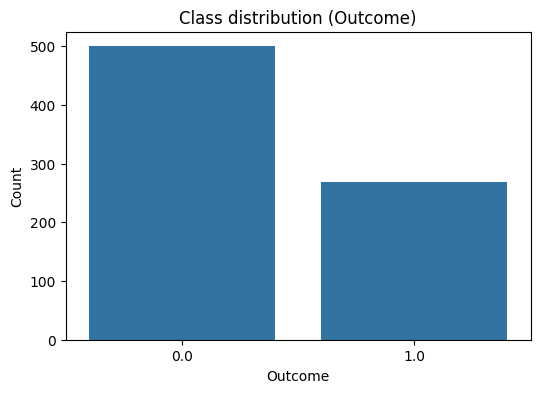


5. Correlation matrix:
                          Pregnancies  Glucose  BloodPressure  SkinThickness  \
Pregnancies                     1.000    0.128          0.214          0.100   
Glucose                         0.128    1.000          0.223          0.228   
BloodPressure                   0.214    0.223          1.000          0.227   
SkinThickness                   0.100    0.228          0.227          1.000   
Insulin                         0.082    0.581          0.098          0.185   
BMI                             0.022    0.233          0.289          0.648   
DiabetesPedigreeFunction       -0.034    0.137         -0.003          0.115   
Age                             0.544    0.267          0.330          0.167   
Outcome                         0.222    0.495          0.171          0.259   

                          Insulin    BMI  DiabetesPedigreeFunction    Age  \
Pregnancies                 0.082  0.022                    -0.034  0.544   
Glucose              

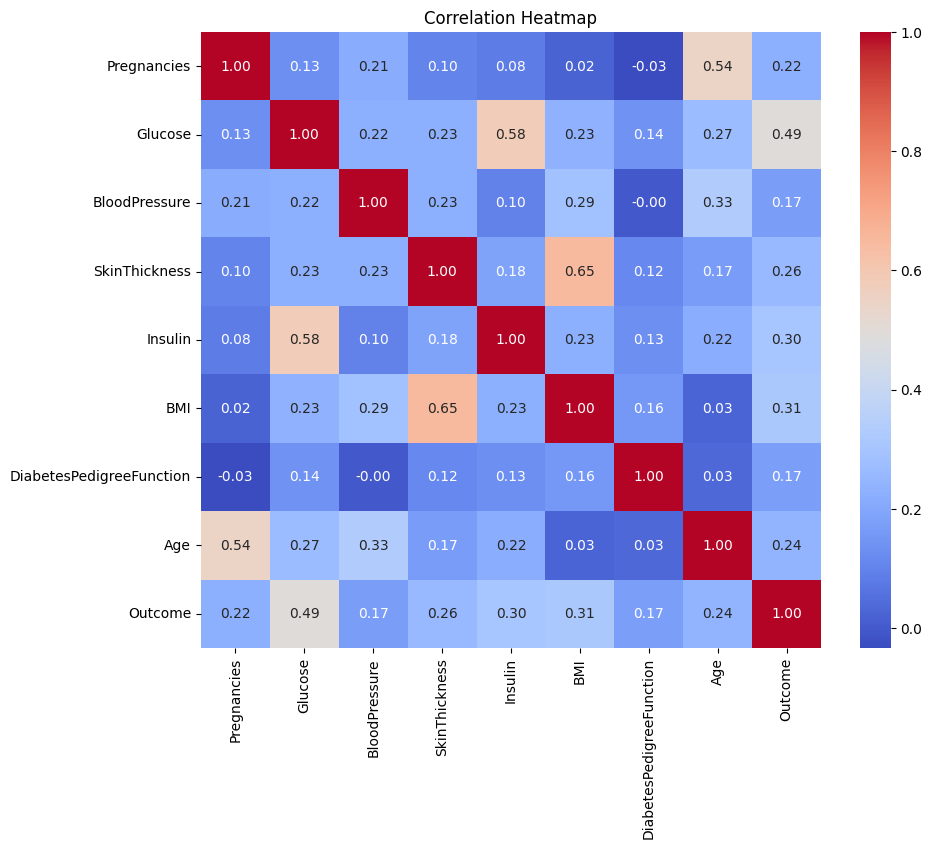


6. Outlier counts using IQR rule:
  Pregnancies: 4 outliers (lower=-6.50, upper=13.50)
  Glucose: 0 outliers (lower=36.00, upper=204.00)
  BloodPressure: 14 outliers (lower=40.00, upper=104.00)
  SkinThickness: 3 outliers (lower=1.00, upper=57.00)
  Insulin: 24 outliers (lower=-94.38, upper=360.62)
  BMI: 8 outliers (lower=13.85, upper=50.25)
  DiabetesPedigreeFunction: 29 outliers (lower=-0.33, upper=1.20)
  Age: 9 outliers (lower=-1.50, upper=66.50)

7. Histograms and boxplots for numeric features:


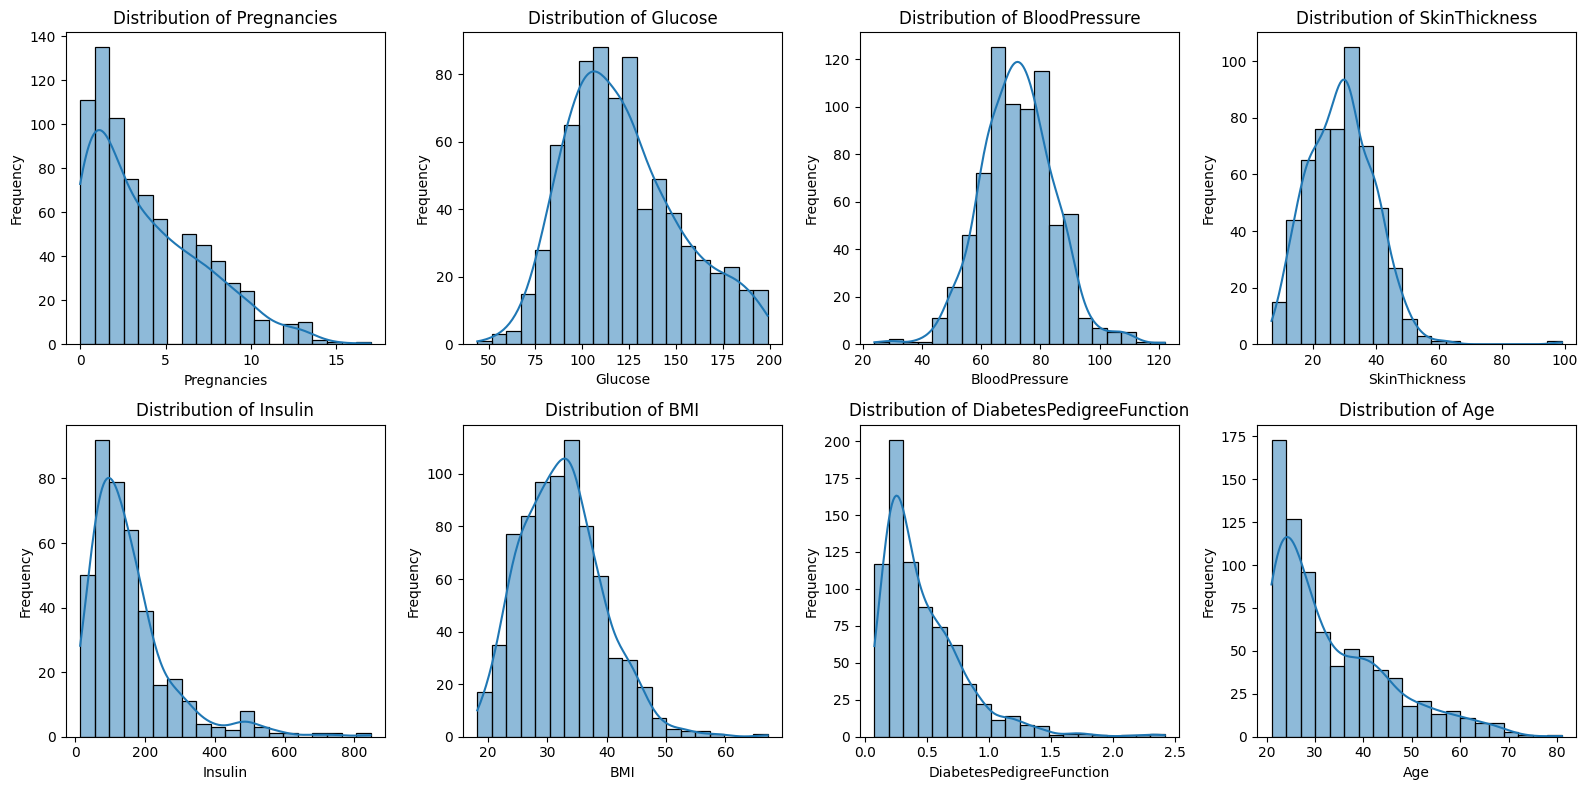

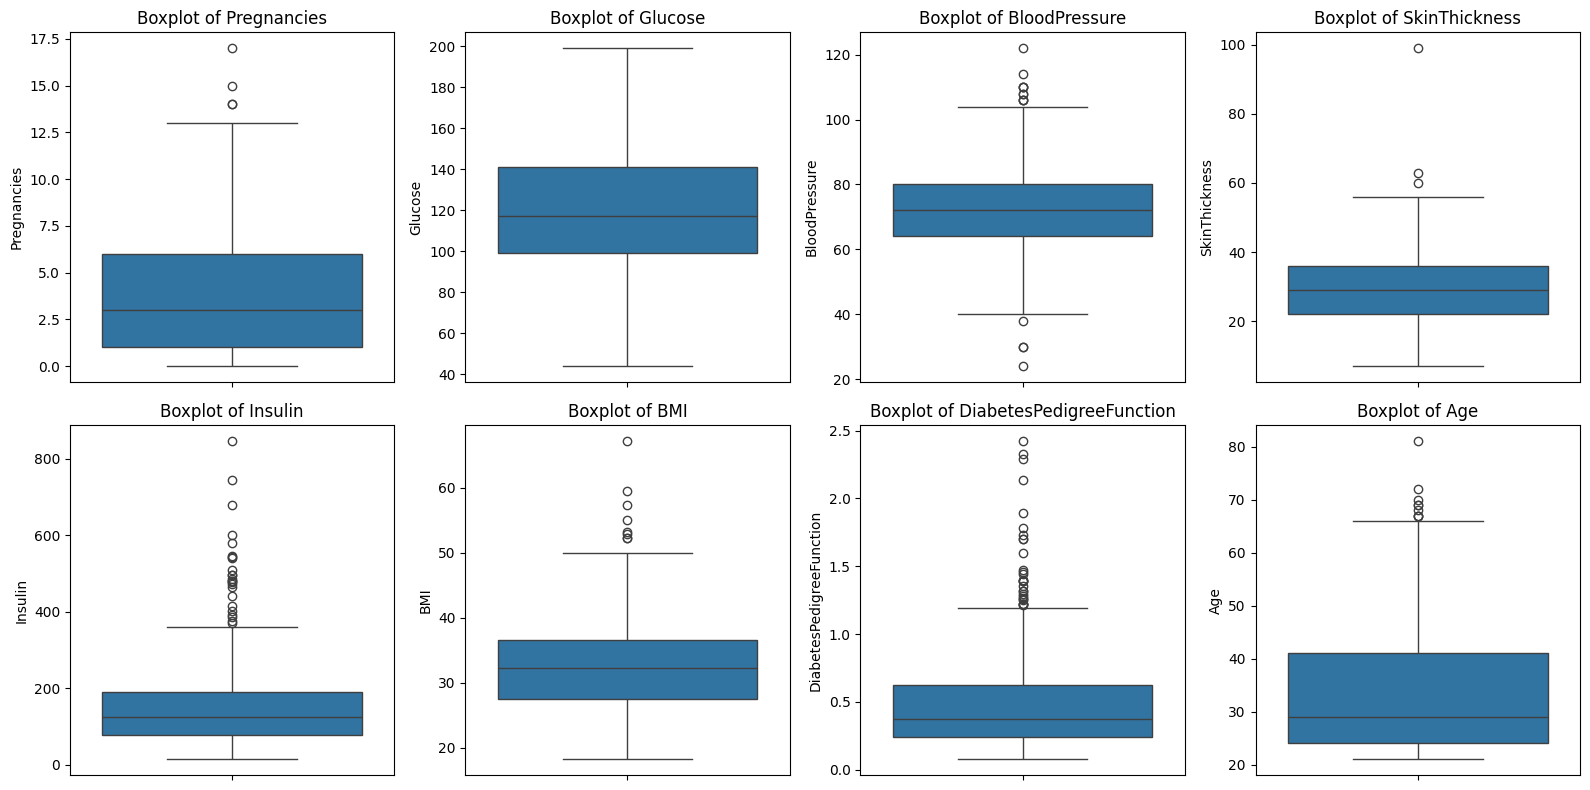


8. Scaling the feature matrix with StandardScaler:
Scaled feature preview:
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.639947  0.866045      -0.031990       0.670643 -0.181541  0.166619   
1    -0.844885 -1.205066      -0.528319      -0.012301 -0.181541 -0.852200   
2     1.233880  2.016662      -0.693761      -0.012301 -0.181541 -1.332500   
3    -0.844885 -1.073567      -0.528319      -0.695245 -0.540642 -0.633881   
4    -1.141852  0.504422      -2.679076       0.670643  0.316566  1.549303   

   DiabetesPedigreeFunction       Age  Outcome  
0                  0.468492  1.425995      1.0  
1                 -0.365061 -0.190672      0.0  
2                  0.604397 -0.105584      1.0  
3                 -0.920763 -1.041549      0.0  
4                  5.484909 -0.020496      1.0  

Final cleaned data shape: (768, 9)
Scaled feature matrix shape: (768, 8)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# ----------------------------
# Part 1: Data Exploration and Preprocessing
# ----------------------------

csv_path = Path('pima-indians-diabetes.csv')
columns = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

# 1) Read and load the data
raw_df = pd.read_csv(csv_path, header=None, names=columns).astype(float)
df = raw_df.copy()

print('1. Dataset shape:', df.shape)
print('\nFirst 5 rows:')
print(df.head())
print('\nData types:')
print(df.dtypes)
print('\nSummary statistics:')
print(df.describe())

# 2) Handle missing values
print('\n2. Missing values in the original data:')
print(df.isnull().sum())

# Zero values for medical measurements are not valid, so treat them as missing.
zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_clean = df.copy()
df_clean.loc[:, zero_as_missing] = df_clean.loc[:, zero_as_missing].replace(0, np.nan)

print('\nMissing values after replacing 0 with NaN:')
print(df_clean.isnull().sum())

# 3) Check duplicate values
duplicates = df_clean.duplicated().sum()
print('\n3. Duplicate rows:', duplicates)

# 4) Check class imbalance
print('\n4. Class distribution (Outcome):')
print(df_clean['Outcome'].value_counts().sort_index())

plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='Outcome')
plt.title('Class distribution (Outcome)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

# 5) Correlation analysis
print('\n5. Correlation matrix:')
correlation_matrix = df_clean.corr(numeric_only=True)
print(correlation_matrix.round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# 6) Outlier detection using IQR
print('\n6. Outlier counts using IQR rule:')
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.drop('Outcome')
for col in numeric_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f'  {col}: {len(outliers)} outliers (lower={lower:.2f}, upper={upper:.2f})')

# 7) Histograms and boxplots
print('\n7. Histograms and boxplots for numeric features:')
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df_clean[col], bins=20, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df_clean[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)
plt.tight_layout()
plt.show()

# 8) Scale / normalize the data
print('\n8. Scaling the feature matrix with StandardScaler:')
median_values = df_clean[zero_as_missing].median()
df_clean[zero_as_missing] = df_clean[zero_as_missing].fillna(median_values)

scaler = StandardScaler()
X = df_clean.drop(columns=['Outcome'])
y = df_clean['Outcome']
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df['Outcome'] = y.values

print('Scaled feature preview:')
print(X_scaled_df.head())
print('\nFinal cleaned data shape:', df_clean.shape)
print('Scaled feature matrix shape:', X_scaled.shape)


Training set shape: (576, 8) (576,)
Testing set shape: (192, 8) (192,)


C:\tfpkg\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121 (484.00 B)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)

Total number of trainable parameters: 121


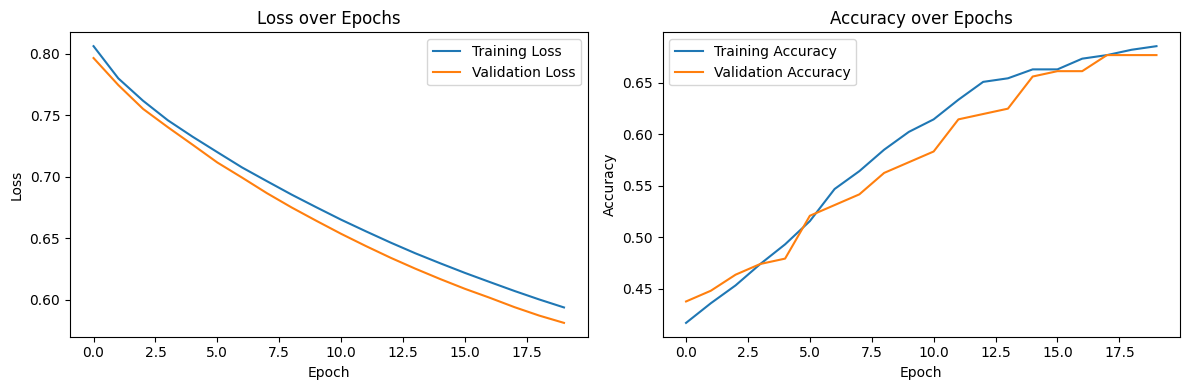

Test Loss: 0.5811872482299805
Test Accuracy: 0.6770833134651184

Interpretation:
- The model uses one hidden layer with 12 neurons and a sigmoid output layer for binary classification.
- RMSprop with learning rate 0.001 and batch size 128 is used as requested.
- Training and validation curves help show whether the model is learning well or overfitting.
- A large gap between training and validation accuracy/loss suggests overfitting.


In [4]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, r"C:\tfpkg")
os.environ["PYTHONPATH"] = r"C:\tfpkg" + os.pathsep + os.environ.get("PYTHONPATH", "")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import RMSprop

# ----------------------------
# Part 2: Build a Baseline Model
# ----------------------------

# Reuse the cleaned and scaled features from Part 1 if available.
# If not, rebuild them from the CSV so the cell is self-contained.
if 'X_scaled' not in globals() or 'y' not in globals():
    csv_path = 'pima-indians-diabetes.csv'
    columns = [
        'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
    ]
    df = pd.read_csv(csv_path, header=None, names=columns).astype(float)
    zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
    df_clean = df.copy()
    df_clean.loc[:, zero_as_missing] = df_clean.loc[:, zero_as_missing].replace(0, np.nan)
    df_clean[zero_as_missing] = df_clean[zero_as_missing].fillna(df_clean[zero_as_missing].median())
    X = df_clean.drop(columns=['Outcome'])
    y = df_clean['Outcome']
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y.to_numpy(),
    test_size=0.25,
    random_state=42,
    stratify=y.to_numpy()
)

print('Training set shape:', X_train.shape, y_train.shape)
print('Testing set shape:', X_test.shape, y_test.shape)

# Build baseline model: one hidden layer with 12 nodes
model = Sequential([
    Dense(12, input_shape=(X_train.shape[1],), activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=RMSprop(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Count parameters
trainable_params = model.count_params()
print('Total number of trainable parameters:', trainable_params)

# Train the model
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=128,
    verbose=0
)

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate on test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print('Test Loss:', loss)
print('Test Accuracy:', accuracy)

# Interpret the results
print('\nInterpretation:')
print('- The model uses one hidden layer with 12 neurons and a sigmoid output layer for binary classification.')
print('- RMSprop with learning rate 0.001 and batch size 128 is used as requested.')
print('- Training and validation curves help show whether the model is learning well or overfitting.')
print('- A large gap between training and validation accuracy/loss suggests overfitting.')


In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

sys.path.insert(0, r"C:\tfpkg")
os.environ["PYTHONPATH"] = r"C:\tfpkg" + os.pathsep + os.environ.get("PYTHONPATH", "")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, RMSprop

# ----------------------------
# Part 3: Find the Best Model
# ----------------------------

# Build or reuse the cleaned/scaled dataset
if 'X_scaled' not in globals() or 'y' not in globals():
    csv_path = 'pima-indians-diabetes.csv'
    columns = [
        'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
    ]
    df = pd.read_csv(csv_path, header=None, names=columns).astype(float)
    zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
    df_clean = df.copy()
    df_clean.loc[:, zero_as_missing] = df_clean.loc[:, zero_as_missing].replace(0, np.nan)
    df_clean[zero_as_missing] = df_clean[zero_as_missing].fillna(df_clean[zero_as_missing].median())
    X = df_clean.drop(columns=['Outcome'])
    y = df_clean['Outcome']
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y.to_numpy(),
    test_size=0.25,
    random_state=42,
    stratify=y.to_numpy()
)

# Four candidate models to compare
configs = [
    ('Model A: ReLU + RMSprop', 12, 'relu', RMSprop(learning_rate=0.001), 20, 128),
    ('Model B: Tanh + Adam', 16, 'tanh', Adam(learning_rate=0.001), 25, 64),
    ('Model C: ReLU + Adam', 24, 'relu', Adam(learning_rate=0.0005), 30, 64),
    ('Model D: LeakyReLU + RMSprop', 20, 'relu', RMSprop(learning_rate=0.0005), 25, 32),
]

results = []

for name, units, activation, optimizer, epochs, batch_size in configs:
    model = Sequential([
        Dense(units, input_shape=(X_train.shape[1],), activation=activation),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=epochs, batch_size=batch_size, verbose=0)
    y_pred = model.predict(X_test, verbose=0).ravel()
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    auc_score = auc(fpr, tpr)
    val_acc = history.history['val_accuracy'][-1]
    val_loss = history.history['val_loss'][-1]
    results.append({
        'name': name,
        'auc': auc_score,
        'val_accuracy': val_acc,
        'val_loss': val_loss,
        'epochs': epochs,
        'batch_size': batch_size,
        'model': model,
        'fpr': fpr,
        'tpr': tpr,
    })

# Plot ROC curves for all models
plt.figure(figsize=(8, 6))
for item in results:
    plt.plot(item['fpr'], item['tpr'], label=f"{item['name']} (AUC = {item['auc']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Four Models')
plt.legend(loc='lower right')
plt.show()

# Select best model by highest validation AUC, then highest validation accuracy
best = max(results, key=lambda x: (x['auc'], x['val_accuracy']))
print('\nBest model by validation AUC:', best['name'])
print('AUC:', best['auc'])
print('Validation Accuracy:', best['val_accuracy'])
print('Validation Loss:', best['val_loss'])

# Save best model weights to a binary file
best['model'].save_weights('best_diabetes_model_weights.weights.h5')
print('Best model weights saved to best_diabetes_model_weights.weights.h5')

# Show comparison table
print('\nModel comparison:')
for item in sorted(results, key=lambda x: x['auc'], reverse=True):
    print(f"- {item['name']}: AUC={item['auc']:.3f}, Val Acc={item['val_accuracy']:.3f}, Val Loss={item['val_loss']:.3f}")

print('\nWhy this model is best:')
print('It gives the highest ROC-AUC and validation accuracy, which usually means better discrimination between diabetic and non-diabetic cases.')


C:\tfpkg\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\tfpkg\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
